In [1]:
from pathlib import Path
import random
import json

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from IPPy.utilities.metrics import PSNR, SSIM

from utils.data_utils import load_normalized_image

# ============================================================
# CONFIGURAZIONE -- percorsi locali
# ============================================================

TEST_DIR = Path("../dataset_resized/test_resized")          # ground truth: root/paziente/slice.png
WTV_DIR = Path("../weighted_tv_reconstructions_tuned/test")  # ricostruzioni Weighted TV CON PARAMETRI TARATI: root/n_angoli/paziente/slice.npy

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

N_ANGLES_CONFIGS = [90, 45, 30, 15]

ANGLE_INTERVALS = {
    90: "[-45°, 45°]",
    45: "[-45°, 45°]",
    30: "(-30°, 30°)",
    15: "(-30°, 30°)",
}

In [2]:
# ============================================================
# Controllo corrispondenza e range/dtype delle ricostruzioni Weighted TV
# (come per TV, il solver forza solo x>=0, non c'e' vincolo superiore:
# aspettati una piccola percentuale di pixel leggermente sopra 1)
# ============================================================

def load_wtv_reconstruction(path: Path) -> np.ndarray:
    image = np.load(path).astype(np.float32)
    return np.clip(image, 0.0, 1.0)


for n_angles in N_ANGLES_CONFIGS:
    wtv_paths = sorted((WTV_DIR / str(n_angles)).rglob("*.npy"))

    global_min, global_max = np.inf, -np.inf
    pixels_below_0 = pixels_above_1 = total_pixels = 0
    missing_gt = 0

    for wtv_path in wtv_paths:
        rel = wtv_path.relative_to(WTV_DIR / str(n_angles))
        gt_path = (TEST_DIR / rel).with_suffix(".png")
        if not gt_path.exists():
            missing_gt += 1

        image = np.load(wtv_path)
        global_min = min(global_min, image.min())
        global_max = max(global_max, image.max())
        pixels_below_0 += np.sum(image < 0)
        pixels_above_1 += np.sum(image > 1)
        total_pixels += image.size

    print(f"\n{n_angles} angoli {ANGLE_INTERVALS[n_angles]}")
    print(f"Ricostruzioni Weighted TV: {len(wtv_paths)}")
    print(f"Ground truth mancanti: {missing_gt}")
    print(f"Range: [{global_min:.4f}, {global_max:.4f}]")
    print(f"Pixel sotto 0: {100 * pixels_below_0 / total_pixels:.6f}%")
    print(f"Pixel sopra 1: {100 * pixels_above_1 / total_pixels:.6f}%")


90 angoli [-45°, 45°]
Ricostruzioni Weighted TV: 327
Ground truth mancanti: 0
Range: [0.0000, 1.2092]
Pixel sotto 0: 0.000000%
Pixel sopra 1: 0.000616%

45 angoli [-45°, 45°]
Ricostruzioni Weighted TV: 327
Ground truth mancanti: 0
Range: [0.0000, 1.3482]
Pixel sotto 0: 0.000000%
Pixel sopra 1: 0.001134%

30 angoli (-30°, 30°)
Ricostruzioni Weighted TV: 327
Ground truth mancanti: 0
Range: [0.0000, 1.3767]
Pixel sotto 0: 0.000000%
Pixel sopra 1: 0.000457%

15 angoli (-30°, 30°)
Ricostruzioni Weighted TV: 327
Ground truth mancanti: 0
Range: [0.0000, 1.1861]
Pixel sotto 0: 0.000000%
Pixel sopra 1: 0.000233%


In [3]:
# ============================================================
# Calcolo PSNR e SSIM tra ricostruzioni Weighted TV e ground truth,
# confronto predizione-per-predizione su tutto il test set
# ============================================================

results_wtv_vs_gt = {}

for n_angles in N_ANGLES_CONFIGS:

    wtv_paths = sorted((WTV_DIR / str(n_angles)).rglob("*.npy"))

    psnr_values = []
    ssim_values = []
    slice_names = []

    for wtv_path in tqdm(wtv_paths, desc=f"Metriche Weighted TV [{n_angles} angoli]"):

        rel = wtv_path.relative_to(WTV_DIR / str(n_angles))
        gt_path = (TEST_DIR / rel).with_suffix(".png")

        if not gt_path.exists():
            print(f"Ground truth non trovata per {wtv_path}")
            continue

        gt = load_normalized_image(gt_path)
        wtv = load_wtv_reconstruction(wtv_path)

        if gt.shape != wtv.shape:
            print(f"Shape diverse per {wtv_path}: GT={gt.shape}, WTV={wtv.shape}")
            continue

        x_true = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)
        x_wtv = torch.from_numpy(wtv).float().unsqueeze(0).unsqueeze(0)

        psnr_values.append(float(PSNR(x_wtv, x_true)))
        ssim_values.append(float(SSIM(x_wtv, x_true)))
        slice_names.append(str(rel))

    results_wtv_vs_gt[n_angles] = {
        "slice": slice_names,
        "PSNR": psnr_values,
        "SSIM": ssim_values,
    }

Metriche Weighted TV [15 angoli]: 100%|██████████| 327/327 [00:08<00:00, 36.64it/s]


In [4]:
# ============================================================
# Risultati medi di PSNR e SSIM per ciascuna configurazione angolare
# -- questa e' la metrica finale da riportare nella relazione
# ============================================================

print("RISULTATI WEIGHTED TV SUL TEST SET")

for n_angles in N_ANGLES_CONFIGS:

    psnr_values = np.array(results_wtv_vs_gt[n_angles]["PSNR"])
    ssim_values = np.array(results_wtv_vs_gt[n_angles]["SSIM"])

    print(f"\n{n_angles} angoli {ANGLE_INTERVALS[n_angles]}")
    print(f"Numero slice: {len(psnr_values)}")
    print(f"PSNR medio: {psnr_values.mean():.2f} ± {psnr_values.std():.2f} dB")
    print(f"SSIM medio: {ssim_values.mean():.4f} ± {ssim_values.std():.4f}")

RISULTATI WEIGHTED TV SUL TEST SET

90 angoli [-45°, 45°]
Numero slice: 327
PSNR medio: 24.06 ± 2.10 dB
SSIM medio: 0.7376 ± 0.0448

45 angoli [-45°, 45°]
Numero slice: 327
PSNR medio: 23.94 ± 2.07 dB
SSIM medio: 0.7309 ± 0.0445

30 angoli (-30°, 30°)
Numero slice: 327
PSNR medio: 21.91 ± 2.36 dB
SSIM medio: 0.6506 ± 0.0587

15 angoli (-30°, 30°)
Numero slice: 327
PSNR medio: 21.62 ± 2.27 dB
SSIM medio: 0.6299 ± 0.0601


In [5]:
# ============================================================
# Salvataggio riepilogo in JSON
# ============================================================

summary_out = {
    str(n_angles): {
        "psnr_mean": float(np.mean(results_wtv_vs_gt[n_angles]["PSNR"])),
        "psnr_std": float(np.std(results_wtv_vs_gt[n_angles]["PSNR"])),
        "ssim_mean": float(np.mean(results_wtv_vs_gt[n_angles]["SSIM"])),
        "ssim_std": float(np.std(results_wtv_vs_gt[n_angles]["SSIM"])),
        "n_slices": len(results_wtv_vs_gt[n_angles]["PSNR"]),
    }
    for n_angles in N_ANGLES_CONFIGS
}

out_path = RESULTS_DIR / "weighted_tv_tuned_test_metrics.json"
with open(out_path, "w") as f:
    json.dump(summary_out, f, indent=2)

print(f"Riepilogo salvato in: {out_path}")

Riepilogo salvato in: ..\results\weighted_tv_tuned_test_metrics.json


Slice scelta a caso: C081\121.npy


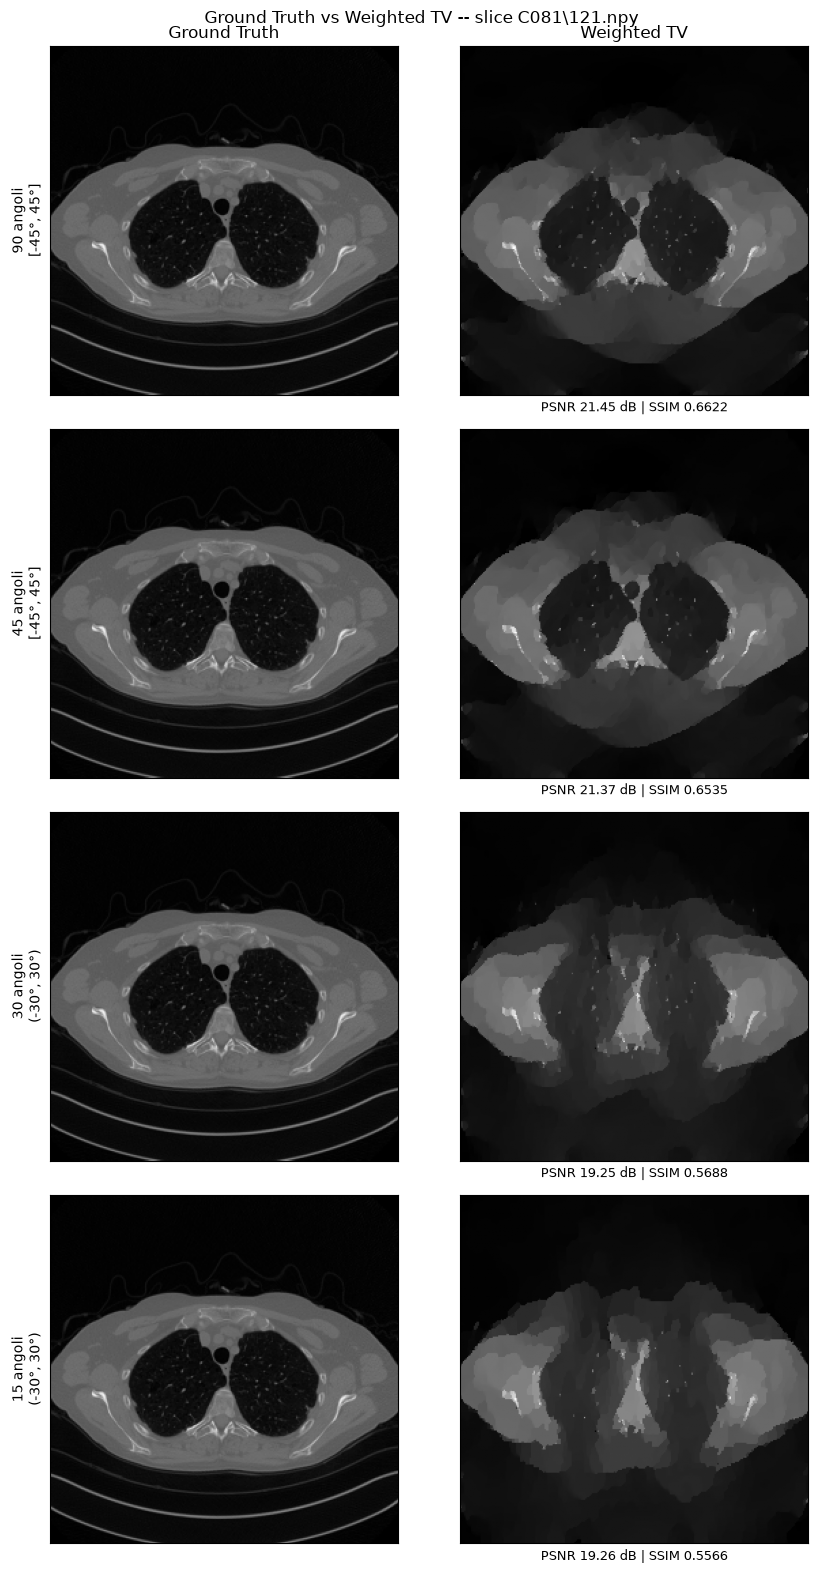

In [6]:
# ============================================================
# Confronto visivo: la STESSA slice mostrata su tutti e 4 gli angoli,
# Ground Truth vs Weighted TV
# ============================================================

random.seed(123)  # stesso seed usato in tutti gli altri notebook di valutazione

reference_paths = sorted((WTV_DIR / "90").rglob("*.npy"))
demo_rel_path = random.choice(reference_paths).relative_to(WTV_DIR / "90")
print(f"Slice scelta a caso: {demo_rel_path}")

gt_path = (TEST_DIR / demo_rel_path).with_suffix(".png")
gt = load_normalized_image(gt_path)
gt_t = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)

fig, axs = plt.subplots(len(N_ANGLES_CONFIGS), 2, figsize=(9, 4 * len(N_ANGLES_CONFIGS)))

for row, n_angles in enumerate(N_ANGLES_CONFIGS):
    wtv = load_wtv_reconstruction(WTV_DIR / str(n_angles) / demo_rel_path)
    wtv_t = torch.from_numpy(wtv).float().unsqueeze(0).unsqueeze(0)
    psnr_val = float(PSNR(wtv_t, gt_t))
    ssim_val = float(SSIM(wtv_t, gt_t))

    axs[row, 0].imshow(gt, cmap="gray", vmin=0, vmax=1)
    axs[row, 0].set_ylabel(f"{n_angles} angoli\n{ANGLE_INTERVALS[n_angles]}", fontsize=10)
    if row == 0:
        axs[row, 0].set_title("Ground Truth")
    axs[row, 0].set_xticks([]); axs[row, 0].set_yticks([])

    axs[row, 1].imshow(wtv, cmap="gray", vmin=0, vmax=1)
    if row == 0:
        axs[row, 1].set_title("Weighted TV")
    axs[row, 1].set_xlabel(f"PSNR {psnr_val:.2f} dB | SSIM {ssim_val:.4f}", fontsize=9)
    axs[row, 1].set_xticks([]); axs[row, 1].set_yticks([])

plt.suptitle(f"Ground Truth vs Weighted TV -- slice {demo_rel_path}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "demo_weighted_tv_tuned_vs_gt.png", dpi=150)
plt.show()